In [18]:
import json
import pathlib
from pprint import pprint

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import bonsai_loop as bl

sc.set_figure_params(figsize=(5, 5))  # type: ignore[call-arg]
sc.set_figure_params(figsize=(5, 5))  # type: ignore[call-arg]

In [13]:
import inspect

from bonsai_loop.bonsai_lib.bonsai.bonsai_dataprocessing import (  # type: ignore[import]
    loadReconstructedTreeAndData,
)
from bonsai_loop.bonsai_lib.bonsai.bonsai_helpers import (  # type: ignore[import]
    Run_Configs,
)

print(inspect.getsource(loadReconstructedTreeAndData))
print(f"{'─' * 88}")
pprint(Run_Configs.__dict__)

def loadReconstructedTreeAndData(args, tree_folder, reprocess_data=False, all_genes=False, all_ranks=True,
                                 get_cell_info=False, corrected_data=True, rel_to_results=False, no_data_needed=False,
                                 single_process=False, keep_original_data=False, calc_loglik=False, get_data=True,
                                 get_posterior_ltqs=False, otherRanksMinimalInfo=False, verbose=True,
                                 calc_posteriors=True):
    """

    :param args:
    :param tree_folder:
    :param reprocess_data:
    :param all_genes:
    :param all_ranks:
    :param get_cell_info:
    :param corrected_data:
    :param rel_to_results:
    :param no_data_needed:
    :param single_process:
    :param keep_original_data:
    :param calc_loglik:
    :param get_data:
    :param get_posterior_ltqs:
    :param otherRanksMinimalInfo:
    :param verbose:
    :param calc_posteriors: This boolean may be false, even when get_posterior_ltqs i

# Reconstruct tree

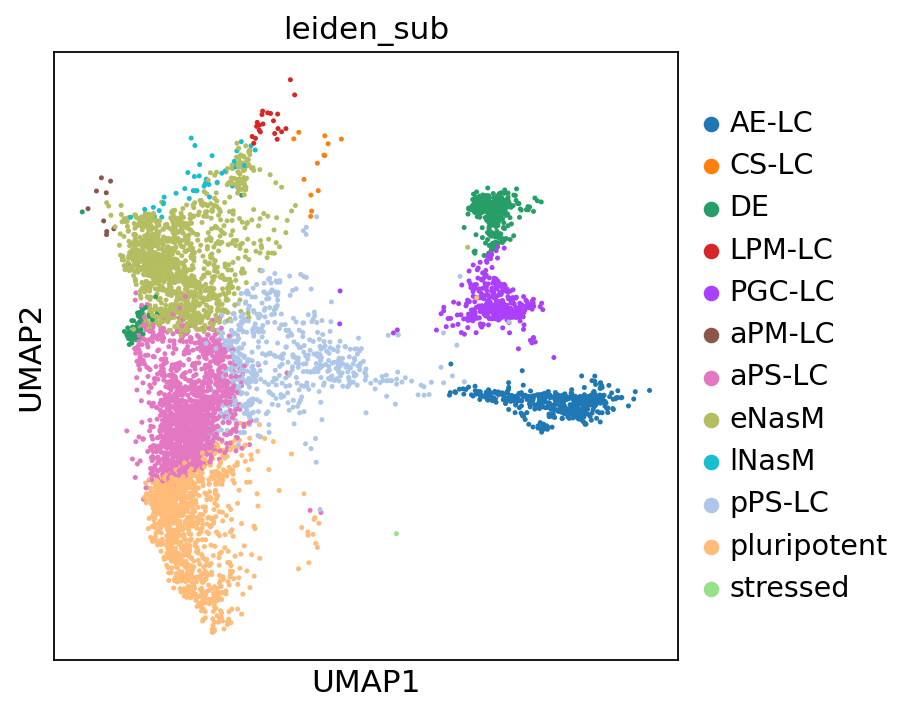

4847

In [4]:
import gc

data_path = pathlib.Path("./data")
adata = sc.read_h5ad(data_path / "adata_timeseries_old_48h-1.h5ad")
meta = pd.read_csv(data_path / "adata_timeseries_old_48h-1_meta.csv", index_col=0)
adata.obs = meta.loc[adata.obs.index]
adata.obsm["X_umap"] = np.array(
    adata.obs.loc[:, ["umap_old_48-96h_x", "umap_old_48-96h_y"]]
)
sc.pl.umap(adata, color=["leiden_sub"])
del meta
bonsai_gastruloid_path = data_path / "Bonsai_48h-1"
gas_bonsai_output_folder = bonsai_gastruloid_path / "final_bonsai_zscore0.75/"
gas_bonsai_config_file = bonsai_gastruloid_path / "used_run_configs.yaml"
gc.collect()

In [12]:
gas_run_configs = Run_Configs(gas_bonsai_config_file)
scData, vert_map = loadReconstructedTreeAndData(
    gas_run_configs,
    gas_bonsai_output_folder,
    rel_to_results=False,
    reprocess_data=False,
    all_ranks=False,
    get_cell_info=True,
    get_posterior_ltqs=True,
)
# compute dsLeafs for dendrogram
scData.tree.root.get_ds_info_for_ladderize()
print(f"{'─' * 88}")
print(scData.tree)
print(f"{'─' * 88}")
print(scData.tree.root)

04-27 14:59:32 mp_print INFO 

Reconstructed tree loaded from: 
data/Bonsai_48h-1/final_bonsai_zscore0.75/edgeInfo.txt 
data/Bonsai_48h-1/final_bonsai_zscore0.75/vertInfo.txt


────────────────────────────────────────────────────────────────────────────────────────
Tree(root=TreeNode(
nodeInd = -1 
nodeId = 'root' 
 childNodes = [5927, 8477] 
 parentNode = None 
tParent = None 
isLeaf = False 
isRoot = True 
isCell = False 
ltqs = None 
_ltqsVars = None 
_W_g = None 
ltqsAIRoot = memmap([ -9.96530558, -11.01004528, -10.04425584, ...,  -8.84288488,
         -9.04318264,  -9.12560264]) 
_ltqsVarsAIRoot = memmap([0.0201755 , 0.02502109, 0.02183851, ..., 0.01829026, 0.01825829,
        0.01790025]) 
_W_gAIRoot = None 
prefactor = None 
dLoglikdtParent = None 
nnnLoglik = None 
cumClosenessNNN = None 
)

loglik=None,nNodes=11069)
────────────────────────────────────────────────────────────────────────────────────────
TreeNode(
nodeInd = -1 
nodeId = 'root' 
 childNodes = [5927, 8477] 
 parentNode = None 
tParent = None 
isLeaf = False 
isRoot = True 
isCell = False 
ltqs = None 
_ltqsVars = None 
_W_g = None 
ltqsAIRoot = memmap([ -9.96530558, -11.01004528, -10.04

## Reroot

In [6]:
gas_node_id_to_vert_ind = {}
with open(gas_bonsai_output_folder / "vertInfo.txt") as f:
    next(f)
    for line in f:
        parts = line.strip().split("\t")
        gas_node_id_to_vert_ind[parts[2]] = int(parts[0])
pprint(dict(list(gas_node_id_to_vert_ind.items())[:15]))

{'ACTCCCACAAGCGGAT-1_48h': 3,
 'CCACCATAGCTCTTCC-1_48h': 12,
 'CCGATCTCAAGCTCTA-1_48h': 14,
 'CCGGTAGTCCCTCTAG-1_48h': 7,
 'CGGGACTGTCCACAGC-1_48h': 10,
 'TCAAGTGTCTGTCAGA-1_48h': 4,
 'internal_0': 1,
 'internal_1': 2,
 'internal_2': 5,
 'internal_3': 6,
 'internal_4': 8,
 'internal_5': 9,
 'internal_6': 11,
 'internal_7': 13,
 'root': 0}


In [15]:
print(scData.tree.root)
print(f"{'─' * 88}")
print(
    f"root has {scData.tree.root.dsLeafs} leaves, should be the same as the total number of real cells"
)

TreeNode(
nodeInd = -1 
nodeId = 'root' 
 childNodes = [5927, 8477] 
 parentNode = None 
tParent = None 
isLeaf = False 
isRoot = True 
isCell = False 
ltqs = None 
_ltqsVars = None 
_W_g = None 
ltqsAIRoot = memmap([ -9.96530558, -11.01004528, -10.04425584, ...,  -8.84288488,
         -9.04318264,  -9.12560264]) 
_ltqsVarsAIRoot = memmap([0.0201755 , 0.02502109, 0.02183851, ..., 0.01829026, 0.01825829,
        0.01790025]) 
_W_gAIRoot = None 
prefactor = None 
dLoglikdtParent = None 
nnnLoglik = None 
cumClosenessNNN = None 
)
────────────────────────────────────────────────────────────────────────────────────────
root has 5927 leaves, should be the same as the total number of real cells


In [8]:
new_root = "internal_1880"
scData.tree.reset_root(gas_node_id_to_vert_ind[new_root])

In [16]:
# root should be updated
scData.tree.root

TreeNode(
nodeInd = -1 
nodeId = 'root' 
 childNodes = [5927, 8477] 
 parentNode = None 
tParent = None 
isLeaf = False 
isRoot = True 
isCell = False 
ltqs = None 
_ltqsVars = None 
_W_g = None 
ltqsAIRoot = memmap([ -9.96530558, -11.01004528, -10.04425584, ...,  -8.84288488,
         -9.04318264,  -9.12560264]) 
_ltqsVarsAIRoot = memmap([0.0201755 , 0.02502109, 0.02183851, ..., 0.01829026, 0.01825829,
        0.01790025]) 
_W_gAIRoot = None 
prefactor = None 
dLoglikdtParent = None 
nnnLoglik = None 
cumClosenessNNN = None 
)

## 

## Contact maps by level

### Bonsai clustering 

In [19]:
f = h5py.File(bonsai_gastruloid_path / "bonsai_vis_data.hdf", "r")
coords = f["layout_coords/node_coords/ly_eq_angle"][:]  # type: ignore[index]
edge_coords = f["layout_coords/edge_coords/ly_eq_angle"][:]  # type: ignore[index]
cell_inds = f["tree_info/cell_inds"][:]  # type: ignore[index]
int_inds = f["tree_info/int_inds"][:]  # type: ignore[index]
metadata = json.loads(f.attrs["metadata_json"])  # type: ignore[index]
gas_cell_ids = metadata["cellIds"]  # type: ignore[index]
gas_vert_to_cell = json.loads(f["vert_info"].attrs["vert_ind_to_cell_inds_json"])  # type: ignore[index]

cell_coords = np.zeros((len(gas_cell_ids), 2))
for vert_idx_str, cell_idx in gas_vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords[ci] = coords[vert_idx]  # type: ignore[index]
    else:
        cell_coords[cell_idx] = coords[vert_idx]  # type: ignore[index]
adata.obsm["X_bonsai"] = cell_coords
f.close()

<Axes: title={'center': 'leiden_sub'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

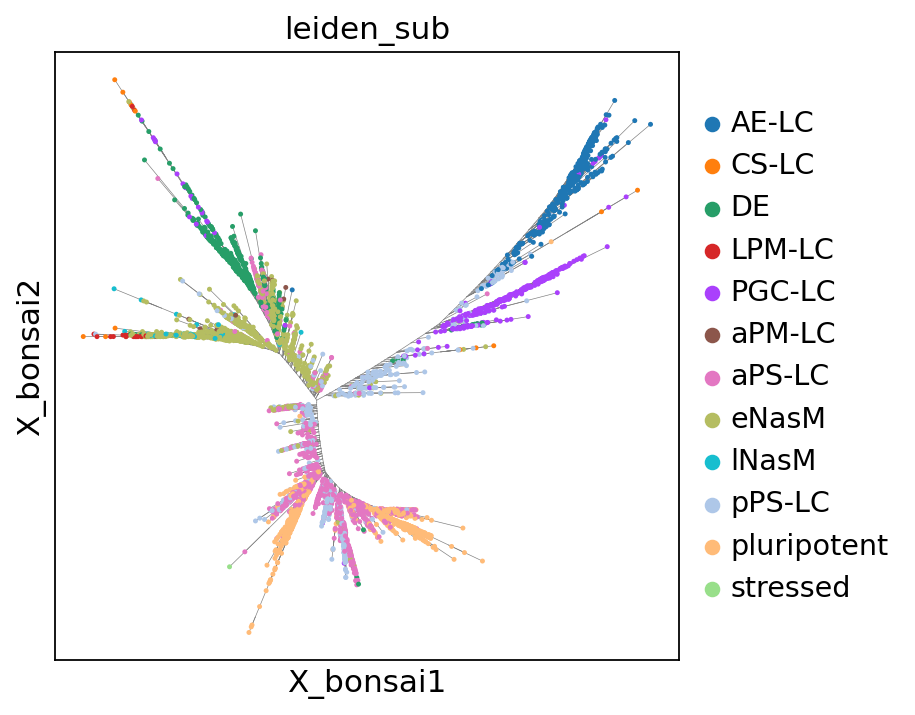

In [20]:
fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:  # type: ignore[index]
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sc.pl.embedding(
    adata, basis="X_bonsai", color="leiden_sub", ax=ax, show=False, s=20, zorder=2
)

In [21]:
from bonsai_loop.bonsai_lib import bonsai_clustering  # type: ignore[import]

with open(gas_bonsai_output_folder / "tree.nwk") as f:
    nwk_str = f.read().strip()
all_clusters, _ = bonsai_clustering.get_min_pdists_clustering_from_nwk_str(
    tree_nwk_str=nwk_str, n_clusters=10
)
gas_clusters = all_clusters[f"annot_bnsi_cluster_n{10}"]
cluster_dict = bonsai_clustering.get_cluster_assignments({"annot": gas_clusters})
adata.obs["bonsai_cluster"] = (
    cluster_dict["annot"].reindex(adata.obs.index).fillna("-1")
)
adata.obs["bonsai_cluster"] = adata.obs["bonsai_cluster"].astype(str).astype("category")

if "bonsai_cluster_colors" in adata.uns:
    del adata.uns["bonsai_cluster_colors"]

04-27 15:03:10 mp_print INFO 
Init min-dist clustering-tree
04-27 15:03:10 mp_print INFO Clustering has created 2 subtrees, 8 branches still to cut.
04-27 15:03:10 mp_print INFO Clustering has created 4 subtrees, 6 branches still to cut.
04-27 15:03:10 mp_print INFO Clustering has created 8 subtrees, 2 branches still to cut.


Clustering done


<Axes: title={'center': 'bonsai_cluster'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

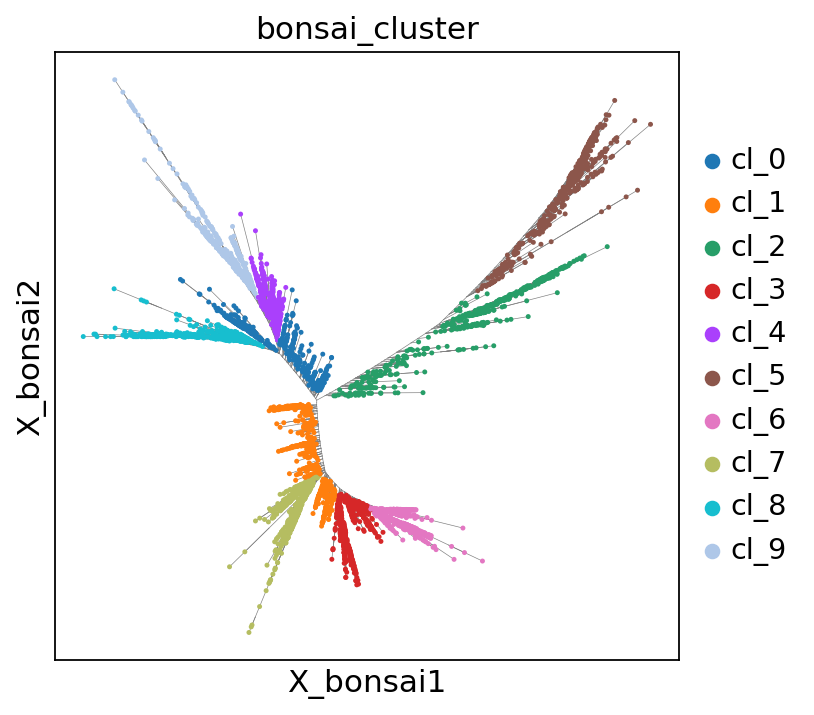

In [22]:
fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:  # type: ignore[index]
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sc.pl.embedding(
    adata, basis="X_bonsai", color="bonsai_cluster", ax=ax, show=False, s=20, zorder=2
)

### Compute node level and label

In [23]:
node_data_lookup = bl.convergence.compute_tree_node_level_and_label(
    tree=scData.tree,
    node_level_type="topological",
    label_lookup_leaves=adata.obs["bonsai_cluster"].to_dict(),
)

compute depth-first ordering of nodes
root node root
compute node level and label


11069it [00:00, 280865.29it/s]


In [24]:
# root node should have n_leaves = number of real cells (n=5927)
print(node_data_lookup["internal_1880"])
# a real cell (a leaf) should have n_leaves = 1
print(node_data_lookup["TTTGTTGTCCATTTCA-1_48h"])

┌───────────────────┬──────────────────────────────────┐
│ attribute         │ value                            │
├───────────────────┼──────────────────────────────────┤
│ tree_node         │ TreeNode(nodeId='internal_1880') │
│ topological_level │ 9                                │
│ geometric_level   │ None                             │
│ identity          │ [(cl_6,1.0)]                     │
│ n_leaves          │ 24                               │
│ ordering_value    │ None                             │
│ dendrogram_coords │ None                             │
│ other_props       │ None                             │
└───────────────────┴──────────────────────────────────┘
┌───────────────────┬───────────────────────────────────────────┐
│ attribute         │ value                                     │
├───────────────────┼───────────────────────────────────────────┤
│ tree_node         │ TreeNode(nodeId='TTTGTTGTCCATTTCA-1_48h') │
│ topological_level │ 0                             

### Compute node ordering

In [25]:
bl.convergence.compute_node_ordering_value(
    tree=scData.tree,
    node_data_lookup=node_data_lookup,
)

compute node ordering using metric bonsai_t_to_root


In [26]:
ordering_leaves = bl.convergence.compute_node_ordering(
    node_data_lookup=node_data_lookup,
    level=0,
    sort_by_identity_first=True,
    ascending=True,
)
pprint(ordering_leaves[:5])

['TCAAGTGTCTGTCAGA-1_48h',
 'TTTAGTCGTGTTAACC-1_48h',
 'CCGGTAGTCCCTCTAG-1_48h',
 'CTGCCATCAACTTGGT-1_48h',
 'GTTGAACCATGGGATG-1_48h']


In [27]:
# check ordering value
# root node should have ordering_value = 0
print(node_data_lookup["internal_1880"])
# a real cell (a leaf) should have ordering_value > 0
print(node_data_lookup["TTTGTTGTCCATTTCA-1_48h"])

┌───────────────────┬──────────────────────────────────┐
│ attribute         │ value                            │
├───────────────────┼──────────────────────────────────┤
│ tree_node         │ TreeNode(nodeId='internal_1880') │
│ topological_level │ 9                                │
│ geometric_level   │ None                             │
│ identity          │ [(cl_6,1.0)]                     │
│ n_leaves          │ 24                               │
│ ordering_value    │ 0.5364289202840001               │
│ dendrogram_coords │ None                             │
│ other_props       │ None                             │
└───────────────────┴──────────────────────────────────┘
┌───────────────────┬───────────────────────────────────────────┐
│ attribute         │ value                                     │
├───────────────────┼───────────────────────────────────────────┤
│ tree_node         │ TreeNode(nodeId='TTTGTTGTCCATTTCA-1_48h') │
│ topological_level │ 0                             